## Generate training dataset
- Phase 1 Generate N random fields

- Phase 2 Run forward simulation

- Phase 3 Check input output dimension and save as HDF5 file 

- For HT-NN
    - Input X dimension for HT-NN: 1x8x8 (inj_events * obs_num)
    - Output Y dimension for HT-NN: 44x26x17 (core element size for sandbox )

In [2]:
# project/
# │
# ├── material/
# │   ├── material_1.dat
# │   ├── material_2.dat
# │   ├── ...
# │   └── material_5.dat
# │
# ├── forward/
# │   │
# │   ├── Event_1/
# │   │   ├── SLE.exe
# │   │   ├── grid.dat
# │   │   ├── node.dat
# │   │   ├── element.dat
# │   │   ├── problem.dat
# │   │   └── ...
# │   │
# │   ├── Event_2/
# │   │   ├── SLE.exe
# │   │   ├── grid.dat
# │   │   └── ...
# │   │
# │   ├── ...
# │   │
# │   └── Event_8/
# │       ├── SLE.exe
# │       ├── grid.dat
# │       └── ...


In [3]:
# PACKAGES
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from crf import crf_process
from  sleio import sle_io
from utilies import *
from pathlib import Path
from subprocess import Popen, PIPE
from multiprocessing import Pool

def col_to_tensor(col, ele_num_x, ele_num_y, ele_num_z):
    
    layer_list = []
    plane_num = ele_num_y* ele_num_x
    for j in range(0, plane_num*ele_num_z, plane_num):
        layer = col[j:j+plane_num].reshape(ele_num_y, ele_num_x)
        layer_list.append(layer.reshape((-1,) + layer.shape)) # layer K
    tensor = np.concatenate(layer_list, axis=0) # concate at z direction
    
    return tensor
    
def tensor_to_col(tensor, ele_num_z):
    
    layer_K_list = []
    for i in range(ele_num_z):
        layer_K = tensor[i, :, :].flatten()
        layer_K_list.append(layer_K)
    col = np.concatenate(layer_K_list, axis = 0)
    
    return col


### Groundwater model

In [18]:
# Create sandbox forward simulation
# Each injection will be a independent events
# Each event contain 1 source well, 8 observations well
# All events keep the same observation well (ob_1~ ob_8)

# Simulation control (unit: mm, sec)
project_name = 'Sandbox_forward'
simulation_control = ('3D', 'steady', 'confined')  # dimension, problem, aquifer

# Geometry control
dx = np.array( [43.5, 25, 20, 20, 20] + [7.5] * 19 + [6, 6, 5.5, 5.5, 6, 6] + [7.5] * 19 + [20, 20, 20, 25, 43.5])
dy = np.array( [31, 20, 20, 20, 10] + [7.5] * 24 + [10, 20, 20, 20, 31])
dz = np.array( [30, 25, 20, 15, 10, 10] + [5] * 11 + [7.5, 7.5] + [10, 10, 10, 25, 30, 35] )

start_coord = (0, 0, 0)         # origin coordinate (x0, y0, z0)
element_num = (54, 34, 25)      # element number in each direction (e_x, e_y, e_z)
element_spacing = (dx, dy, dz)  # element spacing in each direction (len(dx) = e_x-)

# initial condition
init_paras = (350, 0, 0.004, 0.00001, 0.4) # init_h, init_flux, init_K, init_Ss, porosity

# boundary condition
boundary = ('surface', 'UP', 'head')  # method, value, bc_type, bc_value

# injection well info (Each inj_N is a event)
const_rate = 600
inj_time = (0, 600)
inj_1 = ((288.5, 71,  120), 'inj_1', {'rate':const_rate, 'time': inj_time})
inj_2 = ((88.5,  71,  110), 'inj_2', {'rate':const_rate, 'time': inj_time})
inj_3 = ((88.5,  191, 100), 'inj_3', {'rate':const_rate, 'time': inj_time})
inj_4 = ((88.5,  311, 90 ), 'inj_4', {'rate':const_rate, 'time': inj_time})
inj_5 = ((288.5, 311, 120), 'inj_5', {'rate':const_rate, 'time': inj_time})
inj_6 = ((488.5, 311, 110), 'inj_6', {'rate':const_rate, 'time': inj_time})
inj_7 = ((488.5, 191, 100), 'inj_7', {'rate':const_rate, 'time': inj_time})
inj_8 = ((488.5, 71,  90 ), 'inj_8', {'rate':const_rate, 'time': inj_time})

injs = [inj_1, inj_2, inj_3,inj_4, inj_5, inj_6, inj_7, inj_8]

# observation well info (same for all events)
ob_1 = ((188.5, 71,  130), 'Pie_1')
ob_2 = ((88.5, 131,  200), 'Pie_2')
ob_3 = ((88.5, 251,  180), 'Pie_3')
ob_4 = ((188.5, 311, 150), 'Pie_4')
ob_5 = ((388.5, 311, 150), 'Pie_5')
ob_6 = ((488.5, 251, 180), 'Pie_6')
ob_7 = ((488.5, 131, 200), 'Pie_7')
ob_8 = ((388.5, 71,  130), 'Pie_8')

obs = [ob_1, ob_2, ob_3, ob_4, ob_5, ob_6, ob_7, ob_8]

# time info for transient (Not used for steady case)
flag = 'each_time_step'
dt, dt_max, dt_mul, t_max, max_red = (1, 2, 1, 60, 2)
time = (dt, dt_max, dt_mul, t_max, max_red, flag)      
                                

### Forward execution files

In [ ]:
stress_num = len(injs)
event_name = [f"inj_{i+1}" for i in range(stress_num )]

for i in range(stress_num):
    
    project_name = f"forward_{event_name[i]}"
    folder = Path(os.getcwd()) / "forward" / event_name[i]
    fw_ = sle_io(project_name, folder)

    # Geometry 
    fw_.set_parameters(simulation_control)
    fw_.create_geometry(start_coord, element_num, element_spacing)
    fw_.create_initial(init_paras)
    fw_.create_boundary(boundary)

    # events
    fw_.add_stress(1, time, obs, (injs[i],))
    fw_.create_times()
    fw_.create_source()
    fw_.create_observation()

    # simulation 
    fw_.create_function()
    fw_.create_simulation()
    fw_.create_problem()
    fw_.write_forward_input()
    
    print("-"*36)

Project: forward_inj_1
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_1
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_2
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_2
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_3
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_3
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_4
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\forward\inj_4
Simulation in '3D' case, 'confined' aquifer under 'steady' state
Ready for forward simulation!
------------------------------------
Project: forward_inj_5
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\f

## Conditional random field generation

### Prior information

Project: test
Work on folder:C:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\material
-------------- Variogram Fitting for X Direction --------------
Model: Gaussian;  Pseudo r2 = 0.987
Gaussian(dim=3, var=0.0533, len_scale=56.4, nugget=4.07e-05)
Model: Exponential;  Pseudo r2 = 0.920
Exponential(dim=3, var=0.0654, len_scale=88.9)
Model: Stable;  Pseudo r2 = 0.987
Stable(dim=3, var=0.0534, len_scale=63.6, nugget=1.86e-05, alpha=2.0)
Model: Circular;  Pseudo r2 = 0.974
Circular(dim=3, var=0.0531, len_scale=1.24e+02)
Model: Spherical;  Pseudo r2 = 0.967
Spherical(dim=3, var=0.0532, len_scale=1.41e+02)


c:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\.venv\lib\site-packages\gstools\covmodel\plot.py:134: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\.venv\lib\site-packages\gstools\covmodel\tools.py:552: AttributeWarning: Dimension 3 is not appropriate for this model.
  warnings.warn(


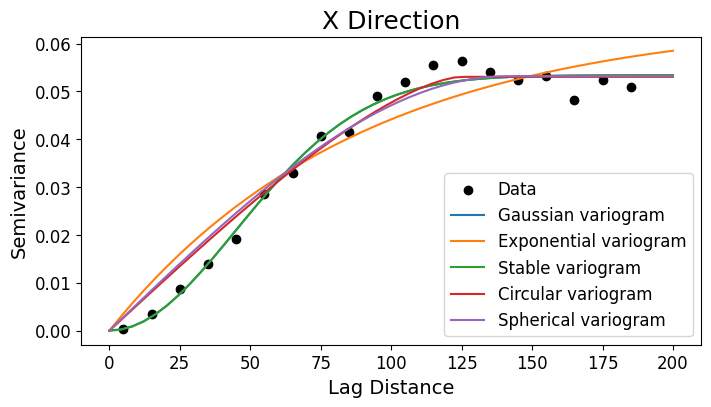

-------------- Variogram Fitting for Y Direction --------------
Model: Gaussian;  Pseudo r2 = 0.973
Gaussian(dim=3, var=0.0492, len_scale=55.7, nugget=0.00279)
Model: Exponential;  Pseudo r2 = 0.969
Exponential(dim=3, var=0.095, len_scale=1.52e+02)
Model: Stable;  Pseudo r2 = 0.980
Stable(dim=3, var=0.0572, len_scale=68.7, alpha=1.47)
Model: Circular;  Pseudo r2 = 0.972
Circular(dim=3, var=0.0531, len_scale=1.27e+02)
Model: Spherical;  Pseudo r2 = 0.973
Spherical(dim=3, var=0.0548, len_scale=1.5e+02)


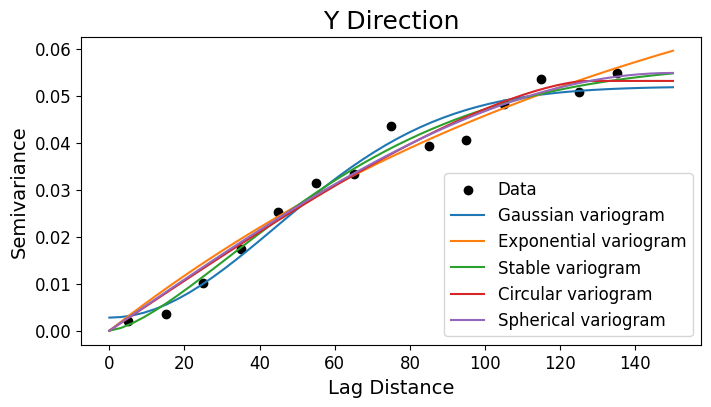

-------------- Variogram Fitting for Z Direction --------------
Model: Gaussian;  Pseudo r2 = 0.964
Gaussian(dim=3, var=0.115, len_scale=51.7)
Model: Exponential;  Pseudo r2 = 0.902
Exponential(dim=3, var=1.04, len_scale=8.75e+02)
Model: Stable;  Pseudo r2 = 0.964
Stable(dim=3, var=0.115, len_scale=58.3, alpha=2.0)
Model: Circular;  Pseudo r2 = 0.911
Circular(dim=3, var=0.106, len_scale=1.03e+02)
Model: Spherical;  Pseudo r2 = 0.907
Spherical(dim=3, var=0.136, len_scale=1.64e+02)


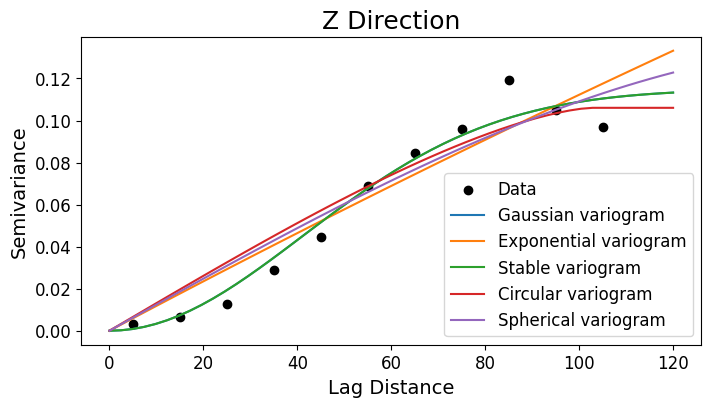

In [19]:
crf = crf_process('test', Path.cwd()/'material')
crf.get_prior('inverse/O-kestimate_prior.dat', 16)
crf.get_core_section(
                        (132, 445),  (96,  286), (95,  195), # get core section
                        resample = True, 
                        grid_size = (120, 60, 80)
                     )

crf.variogram_analysis((200, 10), (150, 10), (120, 10))

### Set crf parameters

In [21]:
crf.set_parameters(injs)
crf.parameters['ens_num'] = 10000
crf.parameters['resample_time'] = 200
crf.parameters['variance'] = 0.06
crf.parameters['c_scale_mul'] = 1.25
crf.parameters['fraction_rate'] = 0.75
crf.parameters['correlation_scale'] = {'x': 56, 'y': 56, 'z': 52}

for parameter, value in crf.parameters.items():
    print(f'{parameter}: {value}')

ens_num: 10000
seed: 20260629
model: Gaussian
variance: 0.06
correlation_scale: {'x': 56, 'y': 56, 'z': 52}
c_scale_mul: 1.25
section_sample_num: 1
fraction_rate: 0.75
resample_time: 200
inj_A_num: 8


### Generate random fields

In [18]:
crf.run_generate_crf(save = True)

process resample group 1/200
------------------------------
Generating field 1   K mean:1.327
Generating field 2   K mean:1.311
Generating field 3   K mean:1.321
Generating field 4   K mean:1.329
Generating field 5   K mean:1.302
Generating field 6   K mean:1.321
Generating field 7   K mean:1.318
Generating field 8   K mean:1.307
Generating field 9   K mean:1.320
Generating field 10   K mean:1.298
Generating field 11   K mean:1.317
Generating field 12   K mean:1.306
Generating field 13   K mean:1.320
Generating field 14   K mean:1.306
Generating field 15   K mean:1.302
Generating field 16   K mean:1.296
Generating field 17   K mean:1.316
Generating field 18   K mean:1.327
Generating field 19   K mean:1.368
Generating field 20   K mean:1.299
Generating field 21   K mean:1.321
Generating field 22   K mean:1.313
Generating field 23   K mean:1.293
Generating field 24   K mean:1.315
Generating field 25   K mean:1.308
Generating field 26   K mean:1.287
Generating field 27   K mean:1.318
Gene

## Run forward simulation

In [ ]:
# import time
# import numpy as np
# import pandas as pd
# from forward import run_single_case
# from pathos.multiprocessing import ProcessingPool as Pool


# ens_num = 1
# stress_num = 8
# n_processes = 16
# field_idx = [i+1 for i in range(ens_num)]
# event_names = [ f"inj_{i+1}" for i in range(stress_num) ]

# for i in range(ens_num):
            
#     with Pool(n_processes) as pool:
        
#         results = pool.map(run_single_case, 
#                            event_names, 
#                            [i + 1] * len(event_names),
#                            [init_paras[0]] * len(event_names)
#                            )
#         print(np.array(results).shape)

(8, 8)


In [ ]:
# def col_to_tensor(col, ele_num_x, ele_num_y, ele_num_z):
    
#     layer_list = []
#     plane_num = ele_num_y* ele_num_x
#     for j in range(0, plane_num*ele_num_z, plane_num):
#         layer = col[j:j+plane_num].reshape(ele_num_y, ele_num_x)
#         layer_list.append(layer.reshape((-1,) + layer.shape)) # layer K
#     tensor = np.concatenate(layer_list, axis=0) # concate at z direction
    
#     return tensor
    
# def tensor_to_col(tensor, ele_num_z):
    
#     layer_K_list = []
#     for i in range(ele_num_z):
#         layer_K = tensor[i, :, :].flatten()
#         layer_K_list.append(layer_K)
#     col = np.concatenate(layer_K_list, axis = 0)
    
#     return col

# def save_to_tensor(field_idx, ele_num_x, ele_num_y, ele_num_z):

#     project_dir = Path.cwd()
#     rf_dir = project_dir/"material"/f"material_{field_idx}.dat"
    
#     df_rf = pd.read_csv( rf_dir , sep="\t", header = 0 )
#     k_col = df_rf['K'].values
    
#     k_tensor = col_to_tensor(k_col, ele_num_x, ele_num_y, ele_num_z)    
    
    
#     return k_tensor

In [ ]:
current_head_list = []
current_para_list = []

for i in range(crf.parameters['ens_num']):

    field_idx = i + 1

    # Read random field
    x_num = len(crf.df_prior_core['x'].unique())
    y_num = len(crf.df_prior_core['y'].unique())
    z_num = len(crf.df_prior_core['z'].unique())
    
    tensor = save_to_tensor(field_idx, x_num, y_num, z_num)
    
    with Pool(n_processes) as pool:
        
        results = pool.map(
            run_single_case, 
            event_names, 
            [i + 1] * len(event_names),
            [init_paras[0]] * len(event_names)
        )
        
        head_matrix = np.expand_dims(np.vstack(results), axis=0)    

    if (
        head_matrix.shape != (1, 8, 8)
        or tensor.shape != (17, 26, 44)
    ):

        print(
            f"SKIP Field {field_idx}: "
            f"X={head_matrix.shape}, "
            f"Y={tensor.shape}"
        )

        continue


    current_head_list.append(head_matrix)
    current_para_list.append(tensor)

    if field_idx % 100 == 0:
        print(
            f"Accepted Field {field_idx}: "
            f"X={head_matrix.shape}, "
            f"Y={tensor.shape}"
        )

Accepted Field 100: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 200: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 300: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 400: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 500: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 600: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 700: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 800: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 900: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1000: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1100: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1200: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1300: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1400: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1500: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1600: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1700: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1800: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 1900: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 2000: X=(1, 8, 8), Y=(17, 26, 44)
Accepted Field 2100: X=(1, 8,

## Check and save training dataset
- *N*       : Ensemble field number
- *X*  input : (*N*, 1, 8, 8)
- *Y*  output: (*N*, 17, 26, 44)

In [ ]:
X_data = np.stack( current_head_list, axis=0 )
Y_data = np.stack( current_para_list, axis=0 )

print("\n==========================================")
print(" Check Dataset")
print("==========================================")
print(f"X shape: {X_data.shape}")
print(f"Y shape: {Y_data.shape}")

if X_data.shape[1:] != (1, 8, 8):
    raise ValueError( f"Invalid X shape: {X_data.shape}")

if Y_data.shape[1:] != (17, 26, 44):
    raise ValueError( f"Invalid Y shape: {Y_data.shape}")

# Create training_data folder
training_dir = os.path.join(  Path.cwd(), "training_data")
os.makedirs( training_dir, exist_ok=True)

# Save to h5df
X_path = os.path.join( training_dir, f"input_X_head_{crf.project_name}.hdf5" )
Y_path = os.path.join( training_dir, f"output_Y_para_{crf.project_name}.hdf5")

with h5py.File(X_path, "w") as f_x:
    f_x.create_dataset( "dataset", data = X_data, compression="gzip")
with h5py.File(Y_path, "w") as f_y:
    f_y.create_dataset( "dataset", data = Y_data, compression="gzip" )

print("\n==========================================")
print("HDF5 Saved")
print("==========================================")
print(f"X file: {X_path}")
print(f"Y file: {Y_path}")
print(f"X shape: {X_data.shape}")
print(f"Y shape: {Y_data.shape}")

NameError: name 'crf' is not defined

In [ ]:
if len(current_head_list) == 0:
    print("No valid fields were collected. restar.")
else:

    # ------------------------------------------
    # Combine all valid fields
    # ------------------------------------------

    X_data = np.stack( current_head_list, axis=0 )

    Y_data = np.stack( current_para_list, axis=0 )

    print("\n==========================================")
    print("Final Dataset")
    print("==========================================")
    print(f"X shape: {X_data.shape}")
    print(f"Y shape: {Y_data.shape}")

    # ------------------------------------------
    # Final shape check
    # ------------------------------------------

    if X_data.shape[1:] != (8, 8):
        raise ValueError(
            f"Invalid X shape: {X_data.shape}"
        )

    if Y_data.shape[1:] != (17, 26, 44):
        raise ValueError(
            f"Invalid Y shape: {Y_data.shape}"
        )

    # ------------------------------------------
    # Create training_data folder
    # ------------------------------------------

    training_dir = os.path.join(
        Path.cwd(),
        "training_data"
    )

    os.makedirs(
        training_dir,
        exist_ok=True
    )

    # ------------------------------------------
    # HDF5 paths
    # ------------------------------------------

    X_path = os.path.join(
        training_dir,
        f"input_X_head.hdf5"
    )

    Y_path = os.path.join(
        training_dir,
        f"output_Y_para.hdf5"
    )

    # ------------------------------------------
    # Save X
    # ------------------------------------------

    with h5py.File(X_path, "w") as f_x:

        f_x.create_dataset(
            "dataset",
            data=X_data,
            compression="gzip"
        )

    # ------------------------------------------
    # Save Y
    # ------------------------------------------

    with h5py.File(Y_path, "w") as f_y:

        f_y.create_dataset(
            "dataset",
            data=Y_data,
            compression="gzip"
        )

    # ------------------------------------------
    # Finished
    # ------------------------------------------

    print("\n==========================================")
    print("HDF5 Saved")
    print("==========================================")
    print(f"X file: {X_path}")
    print(f"Y file: {Y_path}")
    print(f"X shape: {X_data.shape}")
    print(f"Y shape: {Y_data.shape}")


Final Dataset
X shape: (10000, 8, 8)
Y shape: (10000, 17, 26, 44)

HDF5 Saved
X file: c:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\training_data\input_X_head.hdf5
Y file: c:\Users\Ethan\Desktop\ethan\專案\HTNN_Sandbox\training_data\output_Y_para.hdf5
X shape: (10000, 8, 8)
Y shape: (10000, 17, 26, 44)
